# Video Swin — Confusion Matrix · ROC (200개) · **로컬 노트북**

GPU / S3 없이 **PC에서 이 노트북만** 실행합니다.

## 노트북 섹션 (Run All)

| 순서 | 내용 |
|------|------|
| 1 | 환경 설정 + JSON 경로 |
| 2 | 데이터 로드 (200개) |
| 3 | Confusion Matrix (200 combined) |
| 4 | Confusion Matrix (profile별) |
| **5** | **ROC Curve 설명** |
| **6** | **ROC Curve 그래프 + AUC 표** |
| 7–8 | Accuracy / Precision / Recall / F1 |

## 준비
1. 아래 **JSON 2개**를 `docs/notebooks/data/video-swin/`에 둡니다
2. 터미널: `pip install matplotlib seaborn scikit-learn numpy pandas`
3. Cursor에서 이 `.ipynb` 열기 → **Run All** (셀 6까지 ROC 포함)

| 파일 | model | profile |
|------|-------|---------|
| `infer_summary_video_swin_ffpp_vox.json` | video-swin/v1.0.0 | ffpp_vox |
| `infer_summary_video_swin_celebdf.json` | video-swin/v1.0.0 | celebdf |


### JSON 받기 (GPU SSH에서 `unset AWS_PROFILE` 후)

**PC로 복사** (PowerShell):
```powershell
scp sk4team@58.127.241.84:~/notebook-data/video-swin/*.json `
  C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks\data\video-swin\
```

경로가 다르면 **셀 2**의 `LOCAL_FILES`만 수정하세요.

팀 CM 표기: [09-CNN-벤치마크-Confusion-Matrix-ROC.md](../09-CNN-벤치마크-Confusion-Matrix-ROC.md) 부록



In [1]:
# 첫 실행 시 주석 해제:
# !pip install matplotlib seaborn scikit-learn numpy pandas

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve

import matplotlib as mpl
import matplotlib.font_manager as fm

# 노트북에서 그래프(ROC 포함)가 셀 아래에 표시되도록
%matplotlib inline


def _setup_korean_font() -> str:
    """CM 축 라벨(가짜/진짜) 한글이 □로 깨지지 않게 폰트 설정."""
    candidates = [
        "Malgun Gothic",
        "NanumGothic",
        "Nanum Gothic",
        "AppleGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return "default (Korean font not found — install Malgun Gothic or NanumGothic)"


_kr_font = _setup_korean_font()
print(f"matplotlib font: {_kr_font}")

NOTEBOOK_DIR = Path(r"C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks")
DATA_DIR = NOTEBOOK_DIR / "data" / "video-swin"
DATA_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_FILES = {
    "ffpp_vox": DATA_DIR / "infer_summary_video_swin_ffpp_vox.json",
    "celebdf": DATA_DIR / "infer_summary_video_swin_celebdf.json",
}

OUT_DIR = NOTEBOOK_DIR / "output" / "video-swin-cm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_TEAM = ["fake", "real"]

missing = [f"{k}: {p}" for k, p in LOCAL_FILES.items() if not p.is_file()]
if missing:
    print("MISSING — markdown 'JSON 받기' 절차로 아래 파일을 준비하세요:")
    for line in missing:
        print(f"  {line}")
    raise FileNotFoundError(missing[0])
print("OK: both JSON files found")


matplotlib font: Malgun Gothic
OK: both JSON files found


In [2]:
def load_items(path: Path) -> list[dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    if "model" not in data:
        data["model"] = "video-swin/v1.0.0"
    if "profile" not in data:
        name = path.name.lower()
        data["profile"] = "ffpp_vox" if "ffpp" in name else "celebdf"
    if "count" not in data:
        data["count"] = len(data["items"])
    assert data["model"] == "video-swin/v1.0.0", f"expected video-swin/v1.0.0, got {data.get('model')} in {path.name}"
    print(f"{data['model']} / {data['profile']} / n={data['count']}  ({path.name})")
    return data["items"]


items_ffpp = load_items(LOCAL_FILES["ffpp_vox"])
items_celeb = load_items(LOCAL_FILES["celebdf"])
items_all = items_ffpp + items_celeb

print(f"total: {len(items_all)}")

y_true = [it["ground_truth_label"] for it in items_all]
y_pred = [it["pred_label"] for it in items_all]


video-swin/v1.0.0 / ffpp_vox / n=100  (infer_summary_video_swin_ffpp_vox.json)
video-swin/v1.0.0 / celebdf / n=100  (infer_summary_video_swin_celebdf.json)
total: 200


saved C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks\output\video-swin-cm\cm_video_swin_200_combined.png


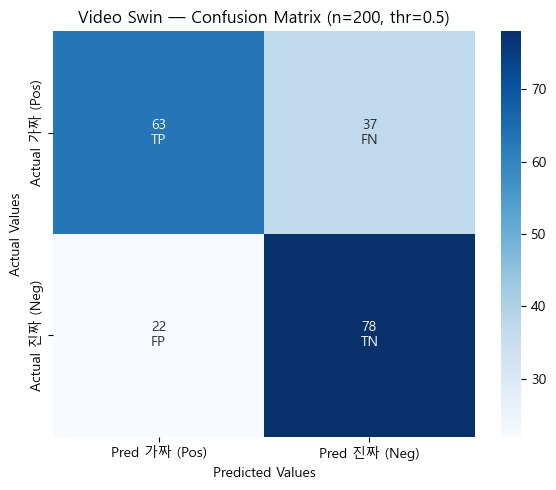

CM (rows=fake,real):
 [[63 37]
 [22 78]]
              precision    recall  f1-score   support

        fake      0.741     0.630     0.681       100
        real      0.678     0.780     0.726       100

    accuracy                          0.705       200
   macro avg      0.710     0.705     0.703       200
weighted avg      0.710     0.705     0.703       200



In [3]:
def plot_team_cm(y_true, y_pred, title: str, out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_TEAM)
    tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    annot = np.array([[f"{tp}\nTP", f"{fn}\nFN"], [f"{fp}\nFP", f"{tn}\nTN"]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 가짜 (Pos)", "Pred 진짜 (Neg)"],
        yticklabels=["Actual 가짜 (Pos)", "Actual 진짜 (Neg)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Actual Values")
    ax.set_title(title)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return cm


cm200 = plot_team_cm(
    y_true,
    y_pred,
    title=f"Video Swin — Confusion Matrix (n={len(items_all)}, thr=0.5)",
    out_path=OUT_DIR / "cm_video_swin_200_combined.png",
)
print("CM (rows=fake,real):\n", cm200)
print(classification_report(y_true, y_pred, labels=LABELS_TEAM, digits=3))


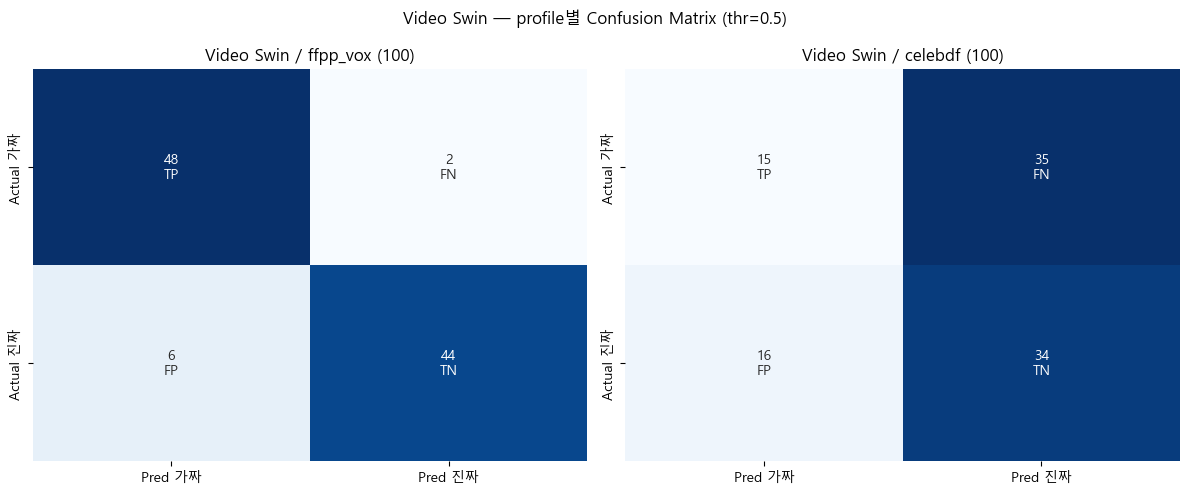

saved C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks\output\video-swin-cm\cm_video_swin_200_by_profile.png


In [4]:
# (선택) 프로필별 2장 — ffpp_vox vs celebdf 비교용
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, items in [
    (axes[0], "ffpp_vox (100)", items_ffpp),
    (axes[1], "celebdf (100)", items_celeb),
]:
    yt = [it["ground_truth_label"] for it in items]
    yp = [it["pred_label"] for it in items]
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    annot = np.array(
        [[f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"], [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]]
    )
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=["Pred 가짜", "Pred 진짜"],
        yticklabels=["Actual 가짜", "Actual 진짜"],
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"Video Swin / {name}")
fig.suptitle("Video Swin — profile별 Confusion Matrix (thr=0.5)")
fig.tight_layout()
split_path = OUT_DIR / "cm_video_swin_200_by_profile.png"
fig.savefig(split_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {split_path}")


## ROC Curve (200개)

**Positive = 가짜(`fake`)** · 점수 = `prob_fake` (0~1)

| 축 | 의미 |
|------|------|
| TPR (세로) | 재현도 — 실제 가짜 중 가짜로 판정한 비율 |
| FPR (가로) | 오탐률 — 실제 진짜 중 가짜로 오판한 비율 |

**AUC** (곡선 아래 면적): 1에 가까울수록 좋음. 점선은 랜덤(0.5). ● = threshold 0.5 지점.

참고: [09-AI-성능-지표-가이드](../../../../docs/ai/09-AI-성능-지표-가이드.md)



ROC Curve (200개) — prob_fake score
saved C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks\output\video-swin-cm\roc_video_swin_200_combined.png


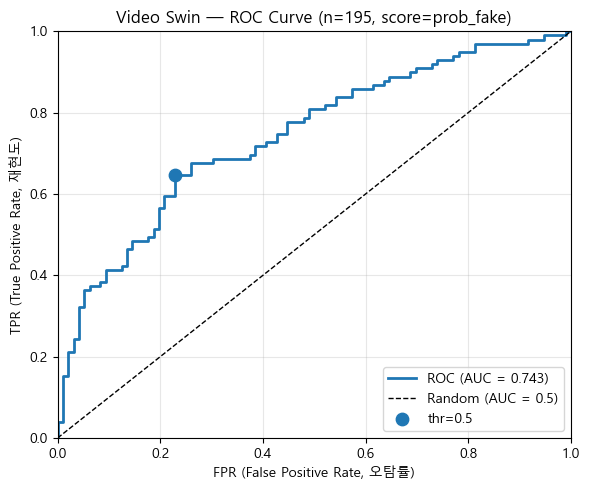

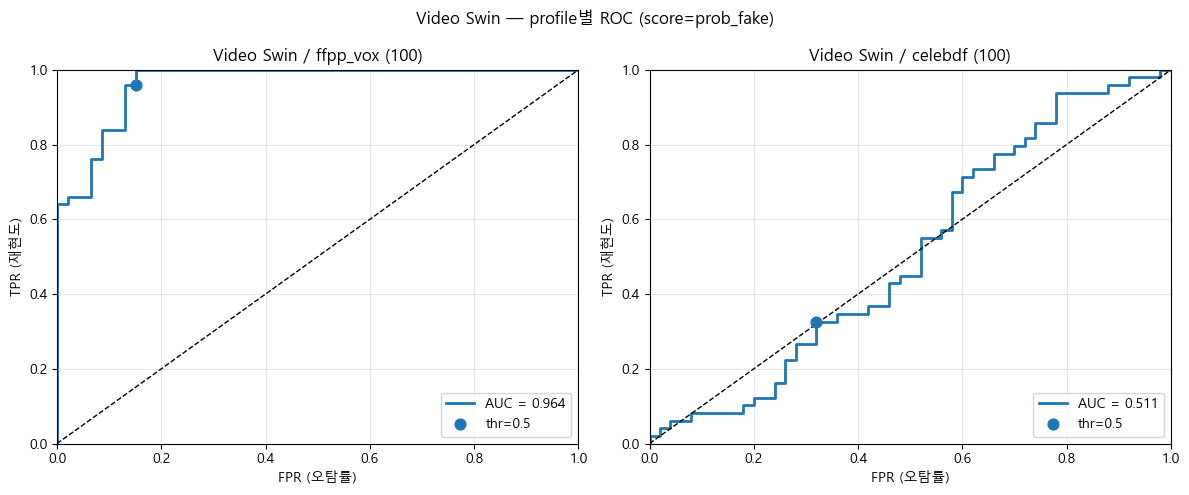

saved C:\Users\user\Desktop\sk-final-forensic\ai-forensic\docs\notebooks\output\video-swin-cm\roc_video_swin_200_by_profile.png


,구분,AUC,n
0,200 combined,0.7435,195
1,ffpp_vox,0.9643,96
2,celebdf,0.5114,99


In [5]:
from sklearn.metrics import roc_curve, auc
print("\n" + "=" * 60)
print("ROC Curve (200개) — prob_fake score")
print("=" * 60)

import pandas as pd
from IPython.display import display


def items_to_roc_arrays(items) -> tuple[np.ndarray, np.ndarray]:
    """Positive=fake(1), score=prob_fake. NaN/inf scores are excluded."""
    y_list, s_list = [], []
    for it in items:
        s = float(it["prob_fake"])
        if np.isfinite(s):
            y_list.append(1 if it["ground_truth_label"] == "fake" else 0)
            s_list.append(s)
    return np.array(y_list), np.array(s_list)


def plot_roc_single(items, title: str, out_path: Path | None = None, thr: float = 0.5) -> float:
    y, s = items_to_roc_arrays(items)
    fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")

    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - thr)))
        ax.scatter(fpr[idx], tpr[idx], s=80, zorder=5, label=f"thr={thr}")

    ax.set_xlabel("FPR (False Positive Rate, 오탐률)")
    ax.set_ylabel("TPR (True Positive Rate, 재현도)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return roc_auc


MODEL_LABEL = "Video Swin"

y200, _ = items_to_roc_arrays(items_all)
auc200 = plot_roc_single(
    items_all,
    f"{MODEL_LABEL} — ROC Curve (n={len(y200)}, score=prob_fake)",
    OUT_DIR / "roc_video_swin_200_combined.png",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
auc_rows = []
for ax, name, items in [
    (axes[0], "ffpp_vox (100)", items_ffpp),
    (axes[1], "celebdf (100)", items_celeb),
]:
    y, s = items_to_roc_arrays(items)
    fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {a:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - 0.5)))
        ax.scatter(fpr[idx], tpr[idx], s=60, zorder=5, label="thr=0.5")
    ax.set_xlabel("FPR (오탐률)")
    ax.set_ylabel("TPR (재현도)")
    ax.set_title(f"{MODEL_LABEL} / {name}")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    profile = name.split()[0]
    auc_rows.append({"구분": profile, "AUC": f"{a:.4f}", "n": len(y)})

fig.suptitle(f"{MODEL_LABEL} — profile별 ROC (score=prob_fake)")
fig.tight_layout()
split_roc = OUT_DIR / "roc_video_swin_200_by_profile.png"
fig.savefig(split_roc, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {split_roc}")

roc_summary = pd.DataFrame(
    [{"구분": "200 combined", "AUC": f"{auc200:.4f}", "n": len(y200)}] + auc_rows
)
display(roc_summary)


## 분류 지표 추출 (Accuracy · Precision · Recall · F1)

Confusion Matrix에서 TP/FN/FP/TN을 읽어 [부록 B](../09-CNN-벤치마크-Confusion-Matrix-ROC.md#부록-b--accuracy--precision--recall--f1-score) 공식으로 계산합니다.

**Positive = 가짜(`fake`)** 기준:

| 지표 | 공식 |
|------|------|
| Accuracy(정확도) | (TP + TN) / (TP + FN + FP + TN) |
| Precision(정밀도) | TP / (TP + FP) |
| Recall(재현도) | TP / (TP + FN) |
| F1-Score(조화평균) | 2 × Precision(정밀도) × Recall(재현도) / (Precision(정밀도) + Recall(재현도)) |


In [6]:
import pandas as pd
from IPython.display import Markdown, display


def metrics_from_cm(cm: np.ndarray) -> dict:
    tp, fn, fp, tn = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    total = tp + fn + fp + tn
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "TP": tp, "FN": fn, "FP": fp, "TN": tn, "n": total,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "acc_num": tp + tn,
        "acc_den": total,
        "prec_num": tp,
        "prec_den": tp + fp,
        "rec_num": tp,
        "rec_den": tp + fn,
        "f1_num": 2 * tp,
        "f1_den": 2 * tp + fp + fn,
    }


def metrics_table(m: dict) -> pd.DataFrame:
    """지표별 분자·분모·값 표."""
    rows = [
        {
            "지표": "Accuracy(정확도)",
            "분자": f"TP + TN = {m['TP']} + {m['TN']} = {m['acc_num']}",
            "분모": f"TP + FN + FP + TN = {m['n']}",
            "수식": f"{m['acc_num']} / {m['acc_den']}",
            "값": f"{m['accuracy']:.4f}",
            "백분율": f"{m['accuracy'] * 100:.2f}%",
        },
        {
            "지표": "Precision(정밀도)",
            "분자": f"TP = {m['prec_num']}",
            "분모": f"TP + FP = {m['TP']} + {m['FP']} = {m['prec_den']}",
            "수식": f"{m['prec_num']} / {m['prec_den']}",
            "값": f"{m['precision']:.4f}",
            "백분율": f"{m['precision'] * 100:.2f}%",
        },
        {
            "지표": "Recall(재현도)",
            "분자": f"TP = {m['rec_num']}",
            "분모": f"TP + FN = {m['TP']} + {m['FN']} = {m['rec_den']}",
            "수식": f"{m['rec_num']} / {m['rec_den']}",
            "값": f"{m['recall']:.4f}",
            "백분율": f"{m['recall'] * 100:.2f}%",
        },
        {
            "지표": "F1-Score(조화평균)",
            "분자": f"2 × TP = 2 × {m['TP']} = {m['f1_num']}",
            "분모": f"2×TP + FP + FN = {m['f1_den']}",
            "수식": f"{m['f1_num']} / {m['f1_den']}",
            "값": f"{m['f1']:.4f}",
            "백분율": f"{m['f1'] * 100:.2f}%",
        },
    ]
    return pd.DataFrame(rows)


def display_metrics_block(label: str, yt, yp) -> dict:
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    m = metrics_from_cm(cm)
    tp, fn, fp, tn = m["TP"], m["FN"], m["FP"], m["TN"]

    display(Markdown(f"### {label}  \n**n = {m['n']}** · Positive = fake (가짜)"))

    display(Markdown(
        f"""
| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = {tp}** | FN = {fn} |
| **Actual real** | FP = {fp} | **TN = {tn}** |
"""
    ))

    display(metrics_table(m))

    p, r = m["precision"], m["recall"]
    display(Markdown(
        f"""
**LaTeX 형태**

$$
\\text{{Accuracy(정확도)}} = \\frac{{TP + TN}}{{TP + FN + FP + TN}}
= \\frac{{{tp} + {tn}}}{{{m['n']}}}
= \\frac{{{m['acc_num']}}}{{{m['acc_den']}}}
= {m['accuracy']:.4f}
$$

$$
\\text{{Precision(정밀도)}} = \\frac{{TP}}{{TP + FP}}
= \\frac{{{tp}}}{{{tp} + {fp}}}
= \\frac{{{m['prec_num']}}}{{{m['prec_den']}}}
= {m['precision']:.4f}
$$

$$
\\text{{Recall(재현도)}} = \\frac{{TP}}{{TP + FN}}
= \\frac{{{tp}}}{{{tp} + {fn}}}
= \\frac{{{m['rec_num']}}}{{{m['rec_den']}}}
= {m['recall']:.4f}
$$

$$
\text{{F1-Score(조화평균)}} = \\frac{{2 \\times \\text{{Precision(정밀도)}} \\times \\text{{Recall(재현도)}}}}{{\\text{{Precision(정밀도)}} + \\text{{Recall(재현도)}}}}
= \\frac{{2 \\times TP}}{{2 \\times TP + FP + FN}}
= \\frac{{{m['f1_num']}}}{{{m['f1_den']}}}
= {m['f1']:.4f}
$$
"""
    ))
    return m


yt_ffpp = [it["ground_truth_label"] for it in items_ffpp]
yp_ffpp = [it["pred_label"] for it in items_ffpp]
yt_celeb = [it["ground_truth_label"] for it in items_celeb]
yp_celeb = [it["pred_label"] for it in items_celeb]

m_all = display_metrics_block("Video Swin 200 (ffpp_vox + celebdf)", y_true, y_pred)
m_ffpp = display_metrics_block("Video Swin · ffpp_vox", yt_ffpp, yp_ffpp)
m_celeb = display_metrics_block("Video Swin · celebdf", yt_celeb, yp_celeb)

summary = pd.DataFrame([
    {
        "구분": "200 combined",
        "TP": m_all["TP"], "FN": m_all["FN"], "FP": m_all["FP"], "TN": m_all["TN"],
        "Accuracy(정확도)": f"{m_all['acc_num']}/{m_all['acc_den']} = {m_all['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_all['prec_num']}/{m_all['prec_den']} = {m_all['precision']:.3f}",
        "Recall(재현도)": f"{m_all['rec_num']}/{m_all['rec_den']} = {m_all['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_all['f1_num']}/{m_all['f1_den']} = {m_all['f1']:.3f}",
    },
    {
        "구분": "ffpp_vox",
        "TP": m_ffpp["TP"], "FN": m_ffpp["FN"], "FP": m_ffpp["FP"], "TN": m_ffpp["TN"],
        "Accuracy(정확도)": f"{m_ffpp['acc_num']}/{m_ffpp['acc_den']} = {m_ffpp['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_ffpp['prec_num']}/{m_ffpp['prec_den']} = {m_ffpp['precision']:.3f}",
        "Recall(재현도)": f"{m_ffpp['rec_num']}/{m_ffpp['rec_den']} = {m_ffpp['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_ffpp['f1_num']}/{m_ffpp['f1_den']} = {m_ffpp['f1']:.3f}",
    },
    {
        "구분": "celebdf",
        "TP": m_celeb["TP"], "FN": m_celeb["FN"], "FP": m_celeb["FP"], "TN": m_celeb["TN"],
        "Accuracy(정확도)": f"{m_celeb['acc_num']}/{m_celeb['acc_den']} = {m_celeb['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_celeb['prec_num']}/{m_celeb['prec_den']} = {m_celeb['precision']:.3f}",
        "Recall(재현도)": f"{m_celeb['rec_num']}/{m_celeb['rec_den']} = {m_celeb['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_celeb['f1_num']}/{m_celeb['f1_den']} = {m_celeb['f1']:.3f}",
    },
])

display(Markdown("### 전체 요약"))
display(summary)


### Video Swin 200 (ffpp_vox + celebdf)  
**n = 200** · Positive = fake (가짜)


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 63** | FN = 37 |
| **Actual real** | FP = 22 | **TN = 78** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 63 + 78 = 141,TP + FN + FP + TN = 200,141 / 200,0.7050,70.50%
1,Precision(정밀도),TP = 63,TP + FP = 63 + 22 = 85,63 / 85,0.7412,74.12%
2,Recall(재현도),TP = 63,TP + FN = 63 + 37 = 100,63 / 100,0.6300,63.00%
3,F1-Score(조화평균),2 × TP = 2 × 63 = 126,2×TP + FP + FN = 185,126 / 185,0.6811,68.11%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{63 + 78}{200}
= \frac{141}{200}
= 0.7050
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{63}{63 + 22}
= \frac{63}{85}
= 0.7412
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{63}{63 + 37}
= \frac{63}{100}
= 0.6300
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{126}{185}
= 0.6811
$$


### Video Swin · ffpp_vox  
**n = 100** · Positive = fake (가짜)

...


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 15** | FN = 35 |
| **Actual real** | FP = 16 | **TN = 34** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 15 + 34 = 49,TP + FN + FP + TN = 100,49 / 100,0.4900,49.00%
1,Precision(정밀도),TP = 15,TP + FP = 15 + 16 = 31,15 / 31,0.4839,48.39%
2,Recall(재현도),TP = 15,TP + FN = 15 + 35 = 50,15 / 50,0.3000,30.00%
3,F1-Score(조화평균),2 × TP = 2 × 15 = 30,2×TP + FP + FN = 81,30 / 81,0.3704,37.04%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{15 + 34}{100}
= \frac{49}{100}
= 0.4900
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{15}{15 + 16}
= \frac{15}{31}
= 0.4839
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{15}{15 + 35}
= \frac{15}{50}
= 0.3000
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{30}{81}
= 0.3704
$$


### 전체 요약

,구분,TP,FN,FP,TN,Accuracy(정확도),Precision(정밀도),Recall(재현도),F1-Score(조화평균)
0,200 combined,63,37,22,78,141/200 = 0.705,63/85 = 0.741,63/100 = 0.630,126/185 = 0.681
1,ffpp_vox,48,2,6,44,92/100 = 0.920,48/54 = 0.889,48/50 = 0.960,96/104 = 0.923
2,celebdf,15,35,16,34,49/100 = 0.490,15/31 = 0.484,15/50 = 0.300,30/81 = 0.370
